# LSTM — Modelo de series temporales de constantes vitales (L1, L2, L3)

**Arquitectura:** LSTM de 2 capas sobre secuencias de vitales (6 features, primeras 2h) concatenado con features estáticas de triage (8 features). Clasificación binaria por target.
**Prerequisito:** ejecutar primero `notebooks/02_features/01_vitalsign_sequences.ipynb`.
**Salidas:** modelos guardados en `models/lstm/<timestamp>/lstm_{L1,L2,L3}.pt` + tabla comparativa.

Se incluye el LSTM para evaluar si la información temporal de las constantes vitales aporta poder discriminante adicional sobre las features estáticas del triage. El bajo número de observaciones temporales (media 2.11 por estancia) limita la ventaja esperada de la arquitectura recurrente.

## 1. Setup

Importaciones y configuración de reproducibilidad. Se fijan `numpy.random.seed`, `torch.manual_seed` y `torch.backends.cudnn.deterministic` para garantizar resultados reproducibles entre ejecuciones.

In [ ]:
import os
import copy
import json
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pack_padded_sequence
from dotenv import load_dotenv
from sklearn.metrics import roc_auc_score, average_precision_score, brier_score_loss
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

load_dotenv(dotenv_path=Path("../../.env"), override=True)
if not os.getenv("MIMIC_IV_ED_PATH"):
    load_dotenv(dotenv_path=Path(".env"), override=True)

DATA          = Path(os.getenv("MIMIC_IV_ED_PATH", ""))
PROCESSED_DIR = Path("../../data/processed")

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'figure.dpi': 150, 'font.size': 10})

TARGETS = ["L1", "L2", "L3"]
TARGET_NAMES = {
    "L1": "Ingreso hospitalario",
    "L2": "Resultado crítico en urgencias",
    "L3": "Intervención crítica en urgencias",
}

## 2. Carga de datos

Se cargan las secuencias preprocesadas (NPZ) y las particiones tabulares (Parquet). Las secuencias deben estar alineadas por posición con las filas del Parquet.

In [ ]:
# Secuencias LSTM (salida del notebook de preprocesamiento de vitalsign)
data_train = np.load(PROCESSED_DIR / "lstm_sequences_train.npz")
data_val   = np.load(PROCESSED_DIR / "lstm_sequences_val.npz")

X_seq_train = data_train["X_seq"]      # (n_train, max_len, 6)
seq_len_train = data_train["seq_len"]  # (n_train,)
X_seq_val   = data_val["X_seq"]
seq_len_val = data_val["seq_len"]

with open(PROCESSED_DIR / "lstm_stats.json") as f:
    lstm_stats = json.load(f)

MAX_LEN = lstm_stats["max_len"]
print(f"X_seq_train: {X_seq_train.shape}  |  X_seq_val: {X_seq_val.shape}")
print(f"MAX_LEN={MAX_LEN} | seq_len train media: {seq_len_train.mean():.2f}")

In [ ]:
# Features estáticas de triage + medrecon (alineadas con el parquet)
df_train = pd.read_parquet(PROCESSED_DIR / "train.parquet")
df_val   = pd.read_parquet(PROCESSED_DIR / "val.parquet")

# n_medications — mismo cálculo que en los notebooks 01 y 02
df_medrecon = pd.read_csv(DATA / "medrecon.csv", low_memory=False,
                          usecols=["stay_id"])
n_meds = df_medrecon.groupby("stay_id").size().rename("n_medications").reset_index()
for df in [df_train, df_val]:
    df.drop(columns=["n_medications"], errors="ignore", inplace=True)
df_train = df_train.merge(n_meds, on="stay_id", how="left")
df_val   = df_val.merge(n_meds, on="stay_id", how="left")
df_train["n_medications"] = df_train["n_medications"].fillna(0).astype(int)
df_val["n_medications"]   = df_val["n_medications"].fillna(0).astype(int)

# Features numéricas de triage (pain incluido tras su parsing a float en el EDA)
STATIC_FEATURES = ["temperature", "heartrate", "resprate", "o2sat", "sbp", "dbp",
                   "acuity", "n_medications", "pain"]

# Imputación y escalado ajustados exclusivamente sobre train
imputer_s = SimpleImputer(strategy="median")
scaler_s  = StandardScaler()
X_static_train = scaler_s.fit_transform(imputer_s.fit_transform(df_train[STATIC_FEATURES]))
X_static_val   = scaler_s.transform(imputer_s.transform(df_val[STATIC_FEATURES]))

# One-hot encoding de arrival_transport (ajustado sobre train)
ohe_s = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
X_transport_train = ohe_s.fit_transform(df_train[["arrival_transport"]].fillna("desconocido"))
X_transport_val   = ohe_s.transform(df_val[["arrival_transport"]].fillna("desconocido"))

# Concatenar features numéricas escaladas + OHE de arrival_transport
X_static_train = np.hstack([X_static_train, X_transport_train]).astype(np.float32)
X_static_val   = np.hstack([X_static_val,   X_transport_val  ]).astype(np.float32)

assert len(X_seq_train) == len(X_static_train) == len(df_train), "Desalineación train"
assert len(X_seq_val)   == len(X_static_val)   == len(df_val),   "Desalineación val"

print(f"X_static_train: {X_static_train.shape}  |  X_static_val: {X_static_val.shape}")
print(f"  → {len(STATIC_FEATURES)} numéricas + {X_transport_train.shape[1]} OHE (arrival_transport)")

## 3. Dataset y modelo

`TriageDataset` encapsula secuencias, features estáticas, longitudes reales e etiquetas en un formato compatible con `DataLoader`. `TriageLSTM` implementa la fusión late-fusion: el estado oculto final del LSTM se concatena con las features estáticas antes del MLP de clasificación.

In [4]:
class TriageDataset(Dataset):
    def __init__(self, X_seq, X_static, seq_len, y):
        self.X_seq    = torch.FloatTensor(X_seq)
        self.X_static = torch.FloatTensor(X_static)
        self.seq_len  = torch.LongTensor(seq_len)
        self.y        = torch.FloatTensor(y)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X_seq[idx], self.X_static[idx], self.seq_len[idx], self.y[idx]

In [5]:
class TriageLSTM(nn.Module):
    """
    2-layer LSTM sobre secuencias de vitales + fusión con features estáticas.

    Entrada:
      x_seq    : (batch, max_len, n_vitals) — secuencias zero-padded
      x_static : (batch, n_static)          — features de triage normalizadas
      seq_len  : (batch,)                   — longitudes reales (sin padding)
    Salida:
      (batch,) — logit (sin sigmoid; usar BCEWithLogitsLoss)
    """
    def __init__(self, n_vitals=6, hidden=64, n_layers=2, n_static=8, dropout=0.3):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=n_vitals,
            hidden_size=hidden,
            num_layers=n_layers,
            batch_first=True,
            dropout=dropout if n_layers > 1 else 0.0,
        )
        self.dropout = nn.Dropout(dropout)
        self.fc1 = nn.Linear(hidden + n_static, 32)
        self.fc2 = nn.Linear(32, 1)
        self.relu = nn.ReLU()

    def forward(self, x_seq, x_static, seq_len):
        packed = pack_padded_sequence(
            x_seq, seq_len.cpu(), batch_first=True, enforce_sorted=False
        )
        _, (h_n, _) = self.lstm(packed)
        h_last = self.dropout(h_n[-1])           # (batch, hidden)
        combined = torch.cat([h_last, x_static], dim=1)
        return self.fc2(self.relu(self.dropout(self.fc1(combined)))).squeeze(1)

## 4. Funciones de entrenamiento y evaluación

`train_epoch` ejecuta un paso de optimización con gradient clipping (max_norm=1.0) sobre el DataLoader de train. `evaluate` acumula probabilidades y etiquetas en modo `no_grad` para calcular las métricas con scikit-learn sin modificar el estado del modelo.

In [6]:
def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0
    for X_seq, X_static, seq_len, y in loader:
        X_seq, X_static, seq_len, y = (
            X_seq.to(device), X_static.to(device), seq_len.to(device), y.to(device)
        )
        optimizer.zero_grad()
        logits = model(X_seq, X_static, seq_len)
        loss = criterion(logits, y)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item() * len(y)
    return total_loss / len(loader.dataset)


@torch.no_grad()
def evaluate(model, loader, device):
    model.eval()
    all_probs, all_y = [], []
    for X_seq, X_static, seq_len, y in loader:
        logits = model(
            X_seq.to(device), X_static.to(device), seq_len.to(device)
        )
        all_probs.append(torch.sigmoid(logits).cpu().numpy())
        all_y.append(y.numpy())
    return np.concatenate(all_probs), np.concatenate(all_y)

## 5. Entrenamiento multi-label: L1, L2, L3

**Hiperparámetros fijos** (suficientes para el TFM; la optimización Optuna se realiza en el notebook `04b`):
- LSTM hidden=64, 2 capas, dropout=0.3
- Adam lr=1e-3, ReduceLROnPlateau (patience=3, factor=0.5)
- Early stopping patience=7, max_epochs=30
- Batch size=512, pos_weight dinámico por target

In [ ]:
HIDDEN     = 64
N_LAYERS   = 2
DROPOUT    = 0.3
LR         = 1e-3
BATCH_SIZE = 512
MAX_EPOCHS = 30
PATIENCE   = 7

final_results = {}
final_models  = {}
history       = {}

for target in TARGETS:
    y_tr = df_train[target].values.astype(np.float32)
    y_v  = df_val[target].values.astype(np.float32)
    pos_weight = float((y_tr == 0).sum() / max((y_tr == 1).sum(), 1))

    print(f"\n{'='*65}")
    print(f"TARGET: {target} — {TARGET_NAMES[target]}")
    print(f"Prevalencia train: {y_tr.mean()*100:.2f}%  |  pos_weight: {pos_weight:.1f}")
    print(f"{'='*65}")

    train_ds = TriageDataset(X_seq_train, X_static_train, seq_len_train, y_tr)
    val_ds   = TriageDataset(X_seq_val,   X_static_val,   seq_len_val,   y_v)
    train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
    val_dl   = DataLoader(val_ds,   batch_size=1024,       shuffle=False, num_workers=0)

    model = TriageLSTM(
        n_vitals=X_seq_train.shape[2],
        hidden=HIDDEN,
        n_layers=N_LAYERS,
        n_static=X_static_train.shape[1],
        dropout=DROPOUT,
    ).to(device)

    criterion = nn.BCEWithLogitsLoss(
        pos_weight=torch.tensor([pos_weight], device=device)
    )
    optimizer = torch.optim.Adam(model.parameters(), lr=LR)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="max", patience=3, factor=0.5
    )

    best_auroc  = 0.0
    best_state  = None
    wait        = 0
    hist        = []

    for epoch in range(1, MAX_EPOCHS + 1):
        tr_loss = train_epoch(model, train_dl, optimizer, criterion, device)
        y_prob, y_true = evaluate(model, val_dl, device)
        val_auroc = roc_auc_score(y_true, y_prob)
        scheduler.step(val_auroc)
        hist.append({"epoch": epoch, "loss": tr_loss, "auroc": val_auroc})
        print(f"  Epoch {epoch:02d} | loss={tr_loss:.4f} | val_AUROC={val_auroc:.4f}"
              f"  {'*' if val_auroc > best_auroc else ''}")

        if val_auroc > best_auroc:
            best_auroc = val_auroc
            best_state = copy.deepcopy(model.state_dict())
            wait = 0
        else:
            wait += 1
            if wait >= PATIENCE:
                print(f"  Early stopping en epoch {epoch}.")
                break

    model.load_state_dict(best_state)
    y_prob, y_true = evaluate(model, val_dl, device)
    auroc = roc_auc_score(y_true, y_prob)
    auprc = average_precision_score(y_true, y_prob)
    brier = brier_score_loss(y_true, y_prob)

    print(f"\n  Mejor modelo — AUROC: {auroc:.4f} | AUPRC: {auprc:.4f} | Brier: {brier:.4f}")
    final_results[target] = {"AUROC": auroc, "AUPRC": auprc, "Brier": brier,
                              "Prev_val": float(y_v.mean())}
    final_models[target]  = model
    history[target]       = hist

print("\nEntrenamiento completado para L1, L2 y L3.")

## 6. Curvas de entrenamiento

Evolución del loss en train y del AUROC en validación por época para cada target. Se usa un eje Y secundario para superponer ambas métricas en la misma figura.

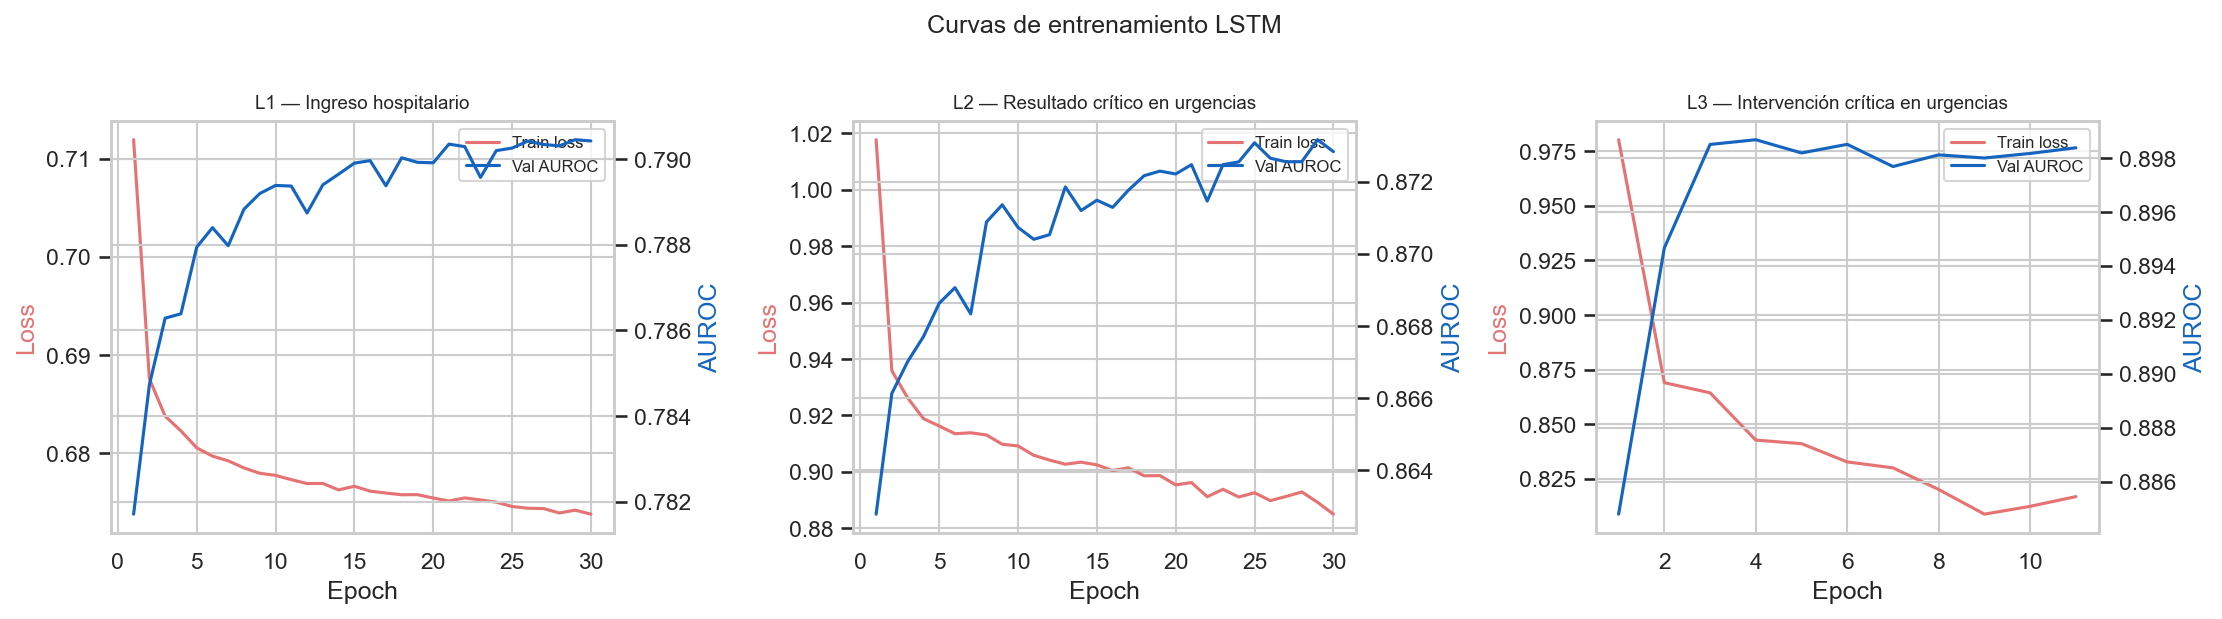

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, target in zip(axes, TARGETS):
    hist_df = pd.DataFrame(history[target])
    ax2 = ax.twinx()
    ax.plot(hist_df["epoch"], hist_df["loss"], color="#E57373", label="Train loss")
    ax2.plot(hist_df["epoch"], hist_df["auroc"], color="#1565C0", label="Val AUROC")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss", color="#E57373")
    ax2.set_ylabel("AUROC", color="#1565C0")
    ax.set_title(f"{target} — {TARGET_NAMES[target]}", fontsize=9)
    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, fontsize=8)
plt.suptitle("Curvas de entrenamiento LSTM", y=1.02)
plt.tight_layout()
plt.show()

## 7. Tabla comparativa: LogReg vs CatBoost vs LSTM

El LSTM supera a LogReg y CatBoost en L3 (AUROC 0.8987), lo que sugiere que la dinámica temporal de los vitales aporta información adicional para los eventos más críticos. Sin embargo, en L1 el LSTM queda por debajo de ambos modelos tabulares, coherente con la escasez de observaciones temporales por estancia (media 2.11 mediciones).

In [9]:
# Resultados anteriores (notebooks 01 y 03)
logreg_results = {
    "L1": {"AUROC": 0.8048, "AUPRC": 0.7102, "Brier": 0.1812},
    "L2": {"AUROC": 0.8617, "AUPRC": 0.0962, "Brier": 0.1596},
    "L3": {"AUROC": 0.8773, "AUPRC": 0.0705, "Brier": 0.1383},
}
catboost_results = {
    "L1": {"AUROC": 0.8314, "AUPRC": 0.7523, "Brier": 0.1684},
    "L2": {"AUROC": 0.8795, "AUPRC": 0.2228, "Brier": 0.1336},
    "L3": {"AUROC": 0.8943, "AUPRC": 0.1141, "Brier": 0.1046},
}

rows = []
for target in TARGETS:
    lr = logreg_results[target]
    cb = catboost_results[target]
    lstm = final_results[target]
    rows.append({
        "Target":         target,
        "LogReg_AUROC":   lr["AUROC"],
        "CatBoost_AUROC": cb["AUROC"],
        "LSTM_AUROC":     lstm["AUROC"],
        "LogReg_AUPRC":   lr["AUPRC"],
        "CatBoost_AUPRC": cb["AUPRC"],
        "LSTM_AUPRC":     lstm["AUPRC"],
        "LogReg_Brier":   lr["Brier"],
        "CatBoost_Brier": cb["Brier"],
        "LSTM_Brier":     lstm["Brier"],
    })

df_comp = pd.DataFrame(rows).set_index("Target")
print("=== LogReg vs CatBoost (Optuna) vs LSTM — Validación ===")
print(df_comp.round(4).to_string())

=== LogReg vs CatBoost (Optuna) vs LSTM — Validación ===
        LogReg_AUROC  CatBoost_AUROC  LSTM_AUROC  LogReg_AUPRC  CatBoost_AUPRC  LSTM_AUPRC  LogReg_Brier  CatBoost_Brier  LSTM_Brier
Target                                                                                                                              
L1            0.8048          0.8314      0.7905        0.7102          0.7523      0.7056        0.1812          0.1684      0.1877
L2            0.8617          0.8795      0.8732        0.0962          0.2228      0.1251        0.1596          0.1336      0.1445
L3            0.8773          0.8943      0.8987        0.0705          0.1141      0.1325        0.1383          0.1046      0.0865


## 8. Guardado de modelos

Se persisten los pesos del modelo (`.pt`), las métricas y la configuración arquitectónica en `models/lstm/<timestamp>/` para su uso en la fase de evaluación y comparación inter-modelo.

In [10]:
TIMESTAMP  = datetime.now().strftime("%Y%m%d_%H%M%S")
MODELS_DIR = Path("../../models/lstm") / TIMESTAMP
MODELS_DIR.mkdir(parents=True, exist_ok=True)

for target, model in final_models.items():
    path = MODELS_DIR / f"lstm_{target}.pt"
    torch.save(model.state_dict(), path)
    print(f"Guardado: {path}")

with open(MODELS_DIR / "results.json", "w") as f:
    json.dump(final_results, f, indent=2)

# Guardar también la configuración del modelo para poder reconstruirlo
model_config = {
    "n_vitals":  int(X_seq_train.shape[2]),
    "hidden":    HIDDEN,
    "n_layers":  N_LAYERS,
    "n_static":  int(X_static_train.shape[1]),
    "dropout":   DROPOUT,
    "max_len":   MAX_LEN,
    "static_features": STATIC_FEATURES,
}
with open(MODELS_DIR / "model_config.json", "w") as f:
    json.dump(model_config, f, indent=2)

print(f"\nArtefactos en: {MODELS_DIR}")

Guardado: ..\..\models\lstm\20260507_230040\lstm_L1.pt
Guardado: ..\..\models\lstm\20260507_230040\lstm_L2.pt
Guardado: ..\..\models\lstm\20260507_230040\lstm_L3.pt

Artefactos en: ..\..\models\lstm\20260507_230040
